# PREDICTING GRID CONGESTION AT THE DISTRIBUTION LEVEL

| Student | Contribution|
|-----------------|-----------------|
| Cui, Xiaoxi    | CIMIS weather data sourcing, EDA, cleaning, and merging into data pipeline. Prediciton Problem #2  |
| Eichenlaub, Brooke    | Lead Data Pipeline Architect, merged in ICA and CALMAC load shape data, spiritual group leader, primary dataframe owner     |
| Healy, Phillip    | Prediction Problem #1, Lead author of abstract, RA and Conclusion section, EDA on CALMAC Load Shapes, some EDA on main dataframe   |
| Tikson, Parker   | EV Data sourcing, EDA, cleaning, and merging into data pipeline, Prediction PRoblem #3|

## Abstract (5 points)
Although this section comes first, you'll write it last.  It should be a ~250 word summary of your project.  1/3rd of the abstract should provide background, 1/3rd should explain what you did, and 1/3rd should explain what you learned.

California’s distribution grid is facing increasing strain as electrification, rooftop solar, and new electric end uses grow faster than historical planning assumptions. Much of this stress appears at the feeder level, where thermal and hosting-capacity limits can restrict additional DER interconnections and slow progress toward statewide climate goals. Existing tools such as PG&E’s Integration Capacity Analysis (ICA) maps provide only static snapshots and are costly to update, leaving planners with limited ability to anticipate when and where future constraints may emerge. This creates a need for lightweight forecasting methods that can complement engineering studies and support short- and medium-term resource allocation.

To help fill this gap, we built a set of predictive models using publicly available data, including CALMAC load shapes, CIMIS weather records, feeder attributes, and indicators of DER and EV adoption. We studied three related questions: predicting continuous feeder headroom by month and hour, classifying whether headroom will fall below 1 MW, and assigning each observation to a low-, medium-, or high-risk congestion tier. We tested linear models, regularized models, decision trees, and ensemble methods using an 80/20 train–test split and cross-validation.
Across all three prediction problems, Random Forest models performed far better than linear approaches. For the regression task, the Random Forest reached an RMSE of about 240 kW with an R² near 0.99, compared with errors over 1.5 MW for OLS, Ridge, and Lasso. The classification tasks showed similar improvements, with the Random Forest capturing important non-linear patterns in customer mix, distributed generation, and time-of-day behavior.
These results suggest that lightweight machine-learning models can provide meaningful early signals of feeder stress. This approach can help utilities prioritize upgrades, plan DER programs, and evaluate future grid scenarios with greater confidence.


## Project Background (5 points)
California’s electric grid is undergoing a rapid transformation driven by electricity demand––which is growing for the first time in over a decade––and the accelerated adoption of distributed energy resources (DERs) along with electric products such as electric vehicles (EVs) and heat-pumps. Much of this growth is occurring within the distribution system, which was historically designed for one way power flows and predictable load growth. Rapid load growth due to electrification, paired with two-way power flow systems which export energy in addition to importing it, are key contributors to today’s distribution-grid congestion. This poses a serious challenge for California’s electrification goals and prevents utilities from interconnecting DERs at an acceptable pace. 

Export-driven congestion (i.e. ‘generation congestion’) is especially salient in the Pacific Gas & Electric (PG&E) territory, where rooftop solar and community scale solar projects have been growing quickly. On certain feeders, mid-day exports from large numbers of solar customers already push circuits toward their hosting-capacity limits. When a feeder approaches its generation headroom constraints, PG&E may be unable to interconnect additional solar customers without costly upgrades. Moreover, mid-day generation congestion can lead to solar project curtailment, resulting in wasted energy. 

The primary tool that stakeholders use to understand these constraints today is the Integration Capacity Analysis (ICA) map. ICA provides a snapshot of generation hosting capacity, but it has some limitations. First, ICA represents only current conditions, and is not useful for identifying which where constraints may emerge in future years under growing DER adoption. Second, generating ICA values required PG&E to run computationally intensive engineering models that have little scalability. This makes it difficult for utilities or regulators to re-run ICA projections to produce iterative scenario-based estimates. These limitations create a gap for decision-makers , who lack the ability to forecast where hosting-capacity constraints are likely to emerge. Regulators and program administrators at organizations like Community Choice Aggregators and the California Energy commission implement various programs meant to improve DER adoption and grid health–such as behind-the-meter battery storage programs and load shifting programs, yet maximizing the value of these programs depends on understanding where the grid is most vulnerable.

In this context, a simple and computationally efficient predictive model of feeder-level generation congestion could provide meaningful value to PG&E, regulators, and program administrators. By using readily available inputs, such as load shapes, climate zone characteristics, and EV/DER adoption patterns, such a model can approximate where peak generation is likely to exceed feeder capabilities under future or varied scenarios.  While a simple predictive model could not replace PG&E’s internal engineering studies, it can serve as a complementary tool to identify feeders which may be under stress in future scenarios, using forecasted feature data. The model outputs could be used to strategically target load-shifting and battery storage programs, which help the distribution grid unlock more capacity without making physical infrastructure upgrades. 

California’s experience with flexible load programs emphasizes this need. Statewide programs, like managed EV charging pilots and the Demand Side Grid Support program, have historically struggled with locational targeting. In many cases, programs have underperformed, in part, because enrollment was not targeted to feeders with the most need. A predictive congestion model that identifies feeders likely to face future stress could therefore enable more impactful and cost-effective deployment of these programs.  



## Project Objective (5 points)
In this section you will pose the central objective or objectives for your semester project.  Objectives should be extremely clear, well-defined and clearly cast as forecasting problems.  

The objective of this project is to develop and evaluate machine-learning models that forecast feeder-level congestion (measured as remaining hosting capacity in MW of head room) across PG&E’s distribution system. Using publicly available data sources, including ICA hosting-capacity values, CIMIS weather data, EV and DER adoption indicators, and aggregated CALMAC load-shape features, we construct models capable of predicting both continuous headroom and categorical congestion risk at the feeder and hour level. The purpose of these models is to create a lightweight, frequently updateable forecasting tool that complements PG&E’s ICA maps, which require detailed engineering planning to recompute and are updated only every three months.

Understanding feeder headroom is important because distribution-grid congestion is a major bottleneck to California’s electrification goals. Utilities and regulators need timely and granular indicators of where remaining capacity is shrinking so they can more effectively allocate resources, such as managed charging programs, DER incentives, operational equipment adjustments, or targeted upgrades. Our forecasting framework enables earlier identification of emerging constraints, faster scenario analysis, and more informed planning under increasing load from EVs, heat pumps, and solar adoption.
To meet these objectives, we investigate three forecasting problems:

Continuous Forecasting (Regression):
How much remaining capacity (MW) will a feeder have at hour h of month m?
This supports short-term (0 - 12 month) planning by providing quantitative headroom estimates.


Binary Congestion Classification:
Is a feeder likely to fall below 1 MW of headroom at a given hour?
This framing identifies high-risk near-term overload conditions, guiding operational decisions such as deploying inspections, sensors, or temporary curtailments.


Multi-Category Congestion Risk Tiering:
What is the congestion risk level (low, medium, or high) during hour h of month m?
The model categorizes feeders into actionable risk tiers (e.g., >5 MW, 1 - 5 MW, <1 MW), enabling medium-term (6 - 36 month) planning such as capital upgrades or non-wires alternatives. 

Novelty:
While PG&E’s ICA tool provides high-fidelity engineering estimates, it is updated infrequently due to the labor- and computational-intensive cost of power-flow modeling. Our approach offers a more dynamic alternative that can be updated weekly or daily at minimal computational cost. By training on 2024 historical data and incorporating forecastable variables (weather, DER growth, load-shape seasonality), the resulting model can be used for scenario analysis, producing potential future insights into feeder-level congestion over the next 1 - 2 years.


## Input Data Description (5 points)
Here you will provide an initial description of your data sets, including:
1. The origins of your data.  Where did you get the data?  How were the data collected from the original sources?  You must provide enough information for the reader to be able to access the data themselves.  
2. The structure, granularity, scope, temporality and faithfulness (SGSTF) of your data.  To discuss these attributes you should load the data into one or more data frames (so you'll start building code cells for the first time).  At a minimum, use some basic methods (`.head`, `.loc`, and so on) to provide support for the descriptions you provide for SGSTF. 
3. You should also describe which data fields you will use as your target variables, and which you will use as features.  

### Weather (Solar radiation / Wind speed / Air temperature): 

The weather data used in this study were obtained from the California Irrigation Management Information System (CIMIS) website (https://cimis.water.ca.gov/), which is operated by the California Department of Water Resources (DWR). CIMIS manages a statewide network of over 145 automated weather stations and was developed in 1982 by DWR in collaboration with the University of California, Davis (UC Davis). The primary purpose of CIMIS is to support efficient irrigation and water resource management; however, the meteorological variables it provides are also widely used for environmental and air quality research.

For this project, we downloaded hourly weather data including: Solar radiation, Wind speed and Air temperature

The data were accessed through the CIMIS web portal after logging into the system. Users can select specific stations, time ranges, and sensors before downloading the data in CSV format. To reduce download time and ensure only relevant information was collected, we selected only the required sensors for each station. Because the website allows downloading data for a maximum of five stations at a time, multiple CSV files were downloaded and then aggregated into a single dataset for further analysis.

To present the original dataset downloaded from CIMIS, we used one-sixth of the full dataset as a representative sample because the complete file exceeds 100 MB in size:


In [17]:
import pandas as pd
raw = pd.read_csv(
    "weather/cimis_raw_1.csv",
    skiprows=1,    # skip the "# ---------" line
    engine="python"
)

# First row (row 0) is the header line as a single string
header = raw.iloc[0, 0].split(",")

# Remaining rows are the data, each as a single comma-separated string
data = raw.iloc[1:, 0].str.split(",", expand=True)

# Assign column names
data.columns = header

# clean DataFrame
df = data

df.head(10)

,Stn Id,Stn Name,CIMIS Region,Date,Hour (PST),Jul,Sol Rad (Ly/day),qc,Air Temp (F),qc,Wind Speed (mph),qc
1,2,FivePoints,San Joaquin Valley,1/1/2024,0100,001,0,,47.5,,2.6,
2,2,FivePoints,San Joaquin Valley,1/1/2024,0200,001,0,,46.7,,3.3,
3,2,FivePoints,San Joaquin Valley,1/1/2024,0300,001,0,,46.9,,4.3,
4,2,FivePoints,San Joaquin Valley,1/1/2024,0400,001,0,,45.5,,2.6,
5,2,FivePoints,San Joaquin Valley,1/1/2024,0500,001,0,,44.7,,2.4,
6,2,FivePoints,San Joaquin Valley,1/1/2024,0600,001,0,,45.1,,2.4,
7,2,FivePoints,San Joaquin Valley,1/1/2024,0700,001,1,,44.1,,2.6,
8,2,FivePoints,San Joaquin Valley,1/1/2024,0800,001,48,,43.8,,2.8,
9,2,FivePoints,San Joaquin Valley,1/1/2024,0900,001,92,,47.0,,7.1,
10,2,FivePoints,San Joaquin Valley,1/1/2024,1000,001,225,,49.4,,9.5,


#### Structure:

The dataset is organized in a tabular format where each row represents one weather observation and each column represents a specific variable. The columns include:

-Stn Id (station identifier)<br>
-Stn Name (station name)<br>
-CIMIS Region (geographic region)<br>
-Date (calendar date of observation)<br>
-Hour (PST) (hourly timestamp in Pacific Standard Time)<br>
-Jul (Julian day indicator)<br>
-Sol Rad (Ly/day) (solar radiation)<br>
-Air Temp (F) (air temperature in Fahrenheit)<br>
-Wind Speed (mph) (wind speed in miles per hour)<br>
-Several qc columns that represent data quality control flags

For example, in the first row, Station 2 (FivePoints) recorded weather conditions on 1/1/2024 at 01:00 PST with an air temperature of 47.5°F and wind speed of 2.6 mph.

#### Granularity / Scope / Temporality:

The granularity of the dataset is hourly, station-level measurements (which include all active stations in California) from 1/1/2024 - 12/31/2024.
Each row corresponds to:

-One specific station (e.g., FivePoints)<br>
-One specific date<br>
-One specific hour


In [18]:
df[
    (df['Sol Rad (Ly/day)'] == "") |
    (df['Wind Speed (mph)'] == "") |
    (df['Air Temp (F)'] == "")
]

,Stn Id,Stn Name,CIMIS Region,Date,Hour (PST),Jul,Sol Rad (Ly/day),qc,Air Temp (F),qc,Wind Speed (mph),qc
2580,2,FivePoints,San Joaquin Valley,4/17/2024,1200,108,1222,,,S,3.6,
6474,2,FivePoints,San Joaquin Valley,9/26/2024,1800,270,,M,,M,,M
10890,5,Shafter,San Joaquin Valley,3/28/2024,1800,088,,M,,M,,M
12404,5,Shafter,San Joaquin Valley,5/30/2024,2000,151,,M,,M,,M
13555,5,Shafter,San Joaquin Valley,7/17/2024,1900,199,,M,,M,,M
...,...,...,...,...,...,...,...,...,...,...,...,...
287562,113,King City-Oasis Rd.,Monterey Bay,9/26/2024,1800,270,,M,,M,,M
288187,113,King City-Oasis Rd.,Monterey Bay,10/22/2024,1900,296,,M,,M,,M
293492,114,Arroyo Seco,Monterey Bay,5/30/2024,2000,151,,M,,M,,M
296346,114,Arroyo Seco,Monterey Bay,9/26/2024,1800,270,,M,,M,,M


#### Faithfulness:

The data originate from the California Irrigation Management Information System (CIMIS), a government-operated and scientifically maintained network of automated weather stations. This makes the dataset highly reliable and faithful to real-world conditions.

Also, the presence of qc (quality control) columns indicates that the data undergo validation, increasing trustworthiness.

As expected for sensor-based data collected over long time periods, the dataset contains explicitly flagged missing values, denoted by the code “M” in the Solar Radiation, Air Temperature, and Wind Speed columns. These missing values occur across multiple stations and dates, indicating that the gaps are likely due to system-wide outages, sensor downtime, or data validation failures.

### EV Adoption Data: 

Our EV adoption data come from the California Energy Commission’s Zero Emission Vehicle and Infrastructure Statistics Dashboard (https://www.energy.ca.gov/zevstats, Vehicle_Population_Last_updated_04-30-2025_ada.xlsx), which compiles annual DMV registration data for light-duty vehicles across California. We accessed the “Vehicle Population by ZIP Code” dataset, which reports the number of light duty vehicles registered in each ZIP code by vehicle type. The CEC updates these data annually to reflect registrations from the prior calendar year. The underlying CSVs are freely downloadable from the dashboard.

#### SGSTF Summary:

The dataset is an excel file with one row per ZIP code per year. It offers moderate granularity—ZIP-level detail provides regional EV trends but is coarser than feeder boundaries. Regarding electric vehicles, its scope includes both BEVs and PHEVs, which we sum to represent total EV adoption relevant for load-growth modeling. The data are annual, so we treat EV counts and growth as slow-moving structural features rather than time-varying signals. Faithfulness is high given its DMV origin, though registrations reflect home addresses rather than actual charging locations.

We initially also included public and residential charger data from the same source (different dataset) , but chose to exclude it from our feature set due to strong collinearity with EV population counts. We believed including both variables would inflate their apparent influence and reduce interpretability and had already created a second EV metric (“YoY Change”). 


### CALMAC Load Shape Data:

The CALMAC load shape dataset used in this project originates from the California Measurement Advisory Council (CALMAC) in partnership with PG&E. The load shape datasets used in this project are Granular Profiles (GPs) produced by PG&E and the analytics firm Demand Side Analystics (DSA) using aggregated smart-meter data from non-participating customers. To create these profiles, PG&E groups customers with similar characteristics into predefined segments and averages their hourly electricity consumption. This produces representative load-shape time series that reflect real consumption patterns across PG&E’s service territory.
Because GPs are aggregated and do not contain customer-level data, they satisfy California privacy requirements and can be shared publicly. Their aggregation makes them useful for analysis while avoiding the confidentiality risks associated with releasing individual Advanced Metering Infrastructure(AMI) records (Source: https://www.calmac.org/granular_profiles.asp).
The specific files used in this project include:
- CALMAC_Res_GP_Elec_2024.csv: hourly electric granular profiles
- CALMAC_Residential_Customer_Electric_Characteristics.csv (multiple files): segmentation attributes
- CALMAC_Res_Elec_GP_Segments_and_Counts.csv: participant counts per segment
- CALMAC_Res_Elec_Segment_Cutoffs_Shape.csv and CALMAC_Res_Elec_Segment_Cutoffs_Size.csv: segmentation cutpoints

#### Integration Capacity Analysis Data

##### Origins of Integration Capacity Analysis Data
The Integration Capacity Analysis (ICA) data come from Pacific Gas and Electric Company’s (PG&E) GRIP hosting capacity portal: https://grip.pge.com/
PG&E publishes hosting capacity results as part of its obligations under the CPUC’s Distribution Resource Planning (DRP) proceeding. These data provide generation hosting capacity values per feeder line-section and month-hour 
To obtain feeder hosting capacity data:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Download all Division ZIP files, each representing a PG&E operating division
(e.g., North Valley.zip, San Francisco.zip, Peninsula.zip, etc.)
3. Each division ZIP contains hundreds of feeder-level ZIP archives.

Each feeder ZIP contains a single CSV with hourly ICA values for all line sections on that feeder.
1. The origins of your data.  Where did you get the data?  How were the data collected from the original sources?  You must provide enough information for the reader to be able to access the data themselves.  
2. The structure, granularity, scope, temporality and faithfulness (SGSTF) of your data.  To discuss these attributes you should load the data into one or more data frames (so you'll start building code cells for the first time).  At a minimum, use some basic methods (`.head`, `.loc`, and so on) to provide support for the descriptions you provide for SGSTF. 
3. You should also describe which data fields you will use as your target variables, and which you will use as features.  

To obtain feeder line shapefiles:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Download 'GRIP Shape' files

To obtain feeder charachteristics/metadata:
1. Navigate to PG&E’s ICA hosting capacity dataset portal
2. Click "system" on left side pane
3. Click on the three dots next to "Distribution lines" under "system" menu
4. Click "add to table"
5. Download


#### ICA Data Structure, Granularity, Scope, Temporality
The ICA line section dataset is structured as one CSV per feeder, where each CSV contains rows for every line section on that feeder. Each row corresponds to a unique combination of:
- month (1–12)
- hour (0–23)
- loading_scenario (e.g., 10th, and 90th percentile case)
- loadorgen (“G” for generation, “L” for load)
- ICA limit values, such as hourly_ica_sg or hourly_ica_of
- Line Section ID

##### Temporality
The ICA data is reported by month hour, at the 90th and 10th pctl. This means each row represents the 90th/10th percentile conditions more that line section during a particular month hour, aggregated accross
all days in that month

##### Granularity
The ICA data is bery granular, with one row per line section. Each feeder can have hundreds of line sections. 

## Data Cleaning (10 points)
In this section you will walk through the data cleaning and merging process.  Explain how you make decisions to clean and merge the data.  Explain how you convince yourself that the data don't contain problems that will limit your ability to produce a meaningful analysis from them.   

#### Basic Data Aggregation Principles:

Our data were derived from multiple sources that varied widely in both granularity and scope. To ensure consistency with our prediction objective, we defined our temporal scope as month–hour intervals from January 1, 2024, to December 31, 2024, and our geographic scope as the PG&E service territory. Accordingly, all datasets were aggregated to the month–hour level where necessary. Some datasets were already available at this resolution and required no transformation, while EV data were only available at the annual level and were therefore repeated across all month-hours within each zip code.

At the geographic level, our target variable and several predictors from the ICA dataset were available at the feeder level, while other datasets were provided at the ZIP code or station level (e.g., CIMIS weather data). To align these spatial scales, ZIP code–level data were assigned to all feeders within the same ZIP code, and station-level data were mapped to ZIP codes using the nearest weather station for each ZIP code.

#### Cleaning and Validating CIMIS Data:

To match the temporal structure of the modeling dataset, which operates at the month–hour level, the original hourly CIMIS observations were aggregated by computing average values for each month–hour combination (for example, the average of all observations at 2:00 PM in January for a specific CIMIS station). 

Spatially, CIMIS data are reported at individual weather stations rather than at the feeder level. Because latitude and longitude coordinates were available for each CIMIS station, and a PG&E territory ZIP code shapefile was available, spatial aggregation was performed using geographic proximity. Each CIMIS station was spatially joined to a ZIP code using its coordinates, and for each ZIP code the nearest station was identified. The resulting month–hour weather variables were then assigned to all feeders located within the corresponding ZIP code. This ensured that each feeder was associated with representative local weather conditions while maintaining geographic consistency across the PG&E territory.

Following these cleaning, aggregation, and spatial alignment steps, the final CIMIS dataset provided complete and spatially consistent month–hour profiles of solar radiation, air temperature, and wind speed for use as continuous predictors in the headroom prediction models.

For some CIMIS stations, missing values were present for specific hours and for one or more weather sensors. These rows were not removed during the cleaning process, as doing so would have created temporal gaps in the month–hour weather profiles and reduced data coverage across the study period. Instead, missing values were handled during the modeling stage. Specifically, indicator variables (via dummy encoding) were created for missing entries, and the corresponding values were imputed using average conditions. This approach preserved the completeness of the dataset while minimizing potential bias introduced by missing sensor readings.

After cleaning and merging, the weather_ready_to_merge looks like:

In [55]:
import pandas as pd

df = pd.read_csv("weather/2024_weather_cleaned.csv")
df.head()

,ZIP_CODE,Month,Hour,Sol Rad (Ly/day),Air Temp (F),Wind Speed (mph)
0,90001,1,100,0.000,53.826,2.623
1,90001,1,200,0.000,53.621,2.629
2,90001,1,300,0.000,53.537,2.394
3,90001,1,400,99.619,53.247,2.484
4,90001,1,500,13.905,53.242,2.745


#### Cleaning and Validating EV Data:

We use ZIP-code–level electric vehicle (EV) adoption data from the California Energy Commission’s ZEV Statistics Dashboard, which provides annual, DMV-verified counts of registered Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs). The dataset was filtered for the 2023 and 2024 calendar years and restricted to BEV and PHEV categories. For each ZIP code, we computed total EV counts as well as absolute and percentage growth from 2023 to 2024. These preprocessing steps were conducted in Excel to create a clean tabular dataset ready for integration with the modeling pipeline. During the merge process, ZIP codes were standardized to five-digit strings, duplicate records were removed, and column names were harmonized to match the main modeling dataset.

Structurally, this dataset consists of a single annual snapshot with one row per ZIP code. Because the EV data are only available at the annual level, the values were repeated for every corresponding month–hour observation within each ZIP code when merged with the feeder-level dataset. As a result, EV adoption is treated as a slow-changing structural feature rather than a time-varying signal. Although spatially coarser than feeder boundaries, the EV variables provide an important indicator of long-term load growth and electrification pressure.

After cleaning and merging, the EV_ready_to_merge looks like:


In [56]:
import pandas as pd

df = pd.read_csv("EV_Pop_Growth_23_24.csv")
df.head()

,Zip Code,2023,2024,YoY Change,%change
0,89061,1.0,1.0,0,0.000000
1,90001,295.0,449.0,154,0.522034
2,90002,253.0,396.0,143,0.565217
3,90003,318.0,507.0,189,0.594340
4,90004,1775.0,2241.0,466,0.262535


1.	Climate Zones and ZIP Code Cleaning
The merge pipeline begins by loading California Building Climate Zone shapefiles and ZIP code boundary shapefiles. Both datasets were converted into a shared coordinate reference system to ensure spatial comparability. A spatial intersection was performed to determine which climate zone overlapped most with each ZIP code. ZIPs were assigned to the climate zone with the largest intersecting area instead of centroid, since ZIP shapes are often irregular. The resulting ZIP–climate mapping was validated by verifying that each ZIP received exactly one climate zone assignment and that the set of climate zone labels matched CALMAC documentation. 

2.	CALMAC Load Shape Cleaning
CALMAC residential load shapes were provided as hourly time series for 160 GP profiles. Timestamps were parsed into datetime objects, and hour and month fields were extracted to match the temporal structure of the ICA data. The dataset was then aggregated to gp × month × hour by computing average hourly consumption within each group. Climate zone assignments were merged into this dataset so that only GP profiles corresponding to the assigned climate zone for each ZIP were retained. Consistency checks confirmed that the aggregated table contained the expected number of gp × month × hour combinations and that the climate zone mapping aligned with CALMAC descriptions.

3.	Feeder Shapefile Cleaning and ZIP Assignment
Feeder polygons from PG&E’s FeederDetail_Voltage shapefile were loaded and feederIDs were normalized to remove any leading zeros or extra spacing.  A spatial overlay was used to assign each feeder to the ZIP code representing the largest area of overlap. Approximately two-thirds of feeder polygons did not intersect any ZIP boundary in the shapefile. The definitive reason for this is unknown, but we assume that the missing feeders were in rural areas with low population, and therefore may not have a zip code. However, all feeders that appeared in later merges were successfully assigned ZIP codes, confirming that ZIP assignment was not a source of missing feeders.

4.	Constructing the Feeder Load Matrix
The ZIP–GP lookup was merged with the aggregated CALMAC load shapes to produce feeder–GP–month–hour observations. This dataset was pivoted wide to create one row per feeder × month × hour with one column per GP. GP columns were then summed to compute a single aggregated hourly load value for each feeder–month–hour. This produced a consistent structure for merging with ICA and other features and ensured that non-overlapping GP profiles did not create irregular row counts.

5.	EV Data Cleaning and Merge
ZIP-level EV adoption data for 2023 and 2024 were prepared externally by selecting Battery Electric Vehicle and Plug-in Hybrid Electric Vehicle categories, calculating year-over-year absolute and percentage change, and standardizing ZIP codes to five-digit strings. Duplicates were removed, and column names were matched to the main dataset. During the merge, ZIP codes were normalized in both datasets to prevent mismatch due to inconsistent string formatting.

6.	ICA Data Cleaning and Validation
ICA data arrived in the form of PG&E “division ZIPs,” each containing hundreds of feeder-specific ZIP files. Each inner ZIP held a CSV representing hourly hosting capacity for each line section. Column names were normalized to lowercase and stripped of whitespace. Files missing required fields (month, hour, loadorgen, the selected ICA column) were skipped. Exploratory validation across tens of millions of rows showed that all ICA observations in the raw data were labeled as generation (“G”). No load rows contain headroom data, even when scanning both GICA and LICA file structures. This confirmed that load-side headroom could not be derived from the available data and that generation hosting capacity (hourly_ica_sg) was the only viable ICA measure. ICA values were aggregated across line sections by computing the mean hosting capacity for each feederid × month × hour. Approximately 7.4% of month-hour combinations lacked any corresponding ICA rows in PG&E source files. Missingness checks showed no pattern across hours or months, indicating the gaps originate from PG&E’s dataset rather than the processing pipeline. Feeder IDs extracted from ICA ZIP filenames were normalized by removing leading zeros and trimming whitespace. This normalization ensured that ICA feeder IDs aligned with those in the feeder shapefile and feeder_characteristics metadata file.

7.	Merging ICA, Feeder Metadata, and Weather
The aggregated ICA data were merged onto the feeder load matrix using feederid, month, and hour as keys. Rows with missing ICA were subsequently filtered out to create the final cleaned dataset. Feeder-level metadata from feeder_characteristics.csv was merged by normalizing both feederid columns and removing existing metadata columns to avoid duplicate suffixes. A validation step confirmed that all feeder-level metadata columns merged correctly after correcting for leading zeros in feeder IDs. Finally, weather data were cleaned by converting 100-, 200-, …-formatted hour stamps into 0–23 integers and merged on ZIP × month × hour.

8.	Final Validation
Several validation checks ensured the merged dataset was internally consistent. These included verifying that each feeder-month-hour key appeared only once, confirming that feeder IDs in the final dataset matched those in both ICA files and feeder metadata, and confirming that feeders had an expected distribution across PG&E service territory.

## Data Summary and Exploratory Data Analysis (10 points)

In this section you should provide a tour through some of the basic trends and patterns in your data.  This includes providing initial plots to summarize the data, such as box plots, histograms, trends over time, scatter plots relating one variable or another.  

The exploratory distributions reveal substantial heterogeneity in both system demand and key explanatory variables. Feeder load exhibits a wide, right-skewed distribution with a strong concentration around moderate values and a long upper tail, indicating that while most feeder–hour observations operate under typical demand levels, a smaller subset experiences very high load that likely drives congestion risk. Solar radiation is extremely right-skewed, with most observations clustered near low values and a long tail extending toward high irradiance, reflecting seasonal and diurnal solar patterns and highlighting periods when photovoltaic generation may significantly affect net load and headroom. Air temperature shows a bimodal to moderately right-skewed distribution, with a dense concentration between roughly 45°F and 65°F and a tapering tail toward higher temperatures above 90°F; these extreme heat conditions are particularly important because they coincide with peak cooling demand and elevated congestion risk. Finally, the residential customer count distribution is heavily right-skewed, indicating that most feeders serve relatively small residential populations, while a small number of feeders support very large customer bases and therefore face structurally higher baseline demand. Together, these distributions demonstrate strong non-normality and wide variability across operating conditions, helping explain why nonlinear models perform well and why congestion risk is concentrated among a limited subset of high-load, high-customer-density feeders.

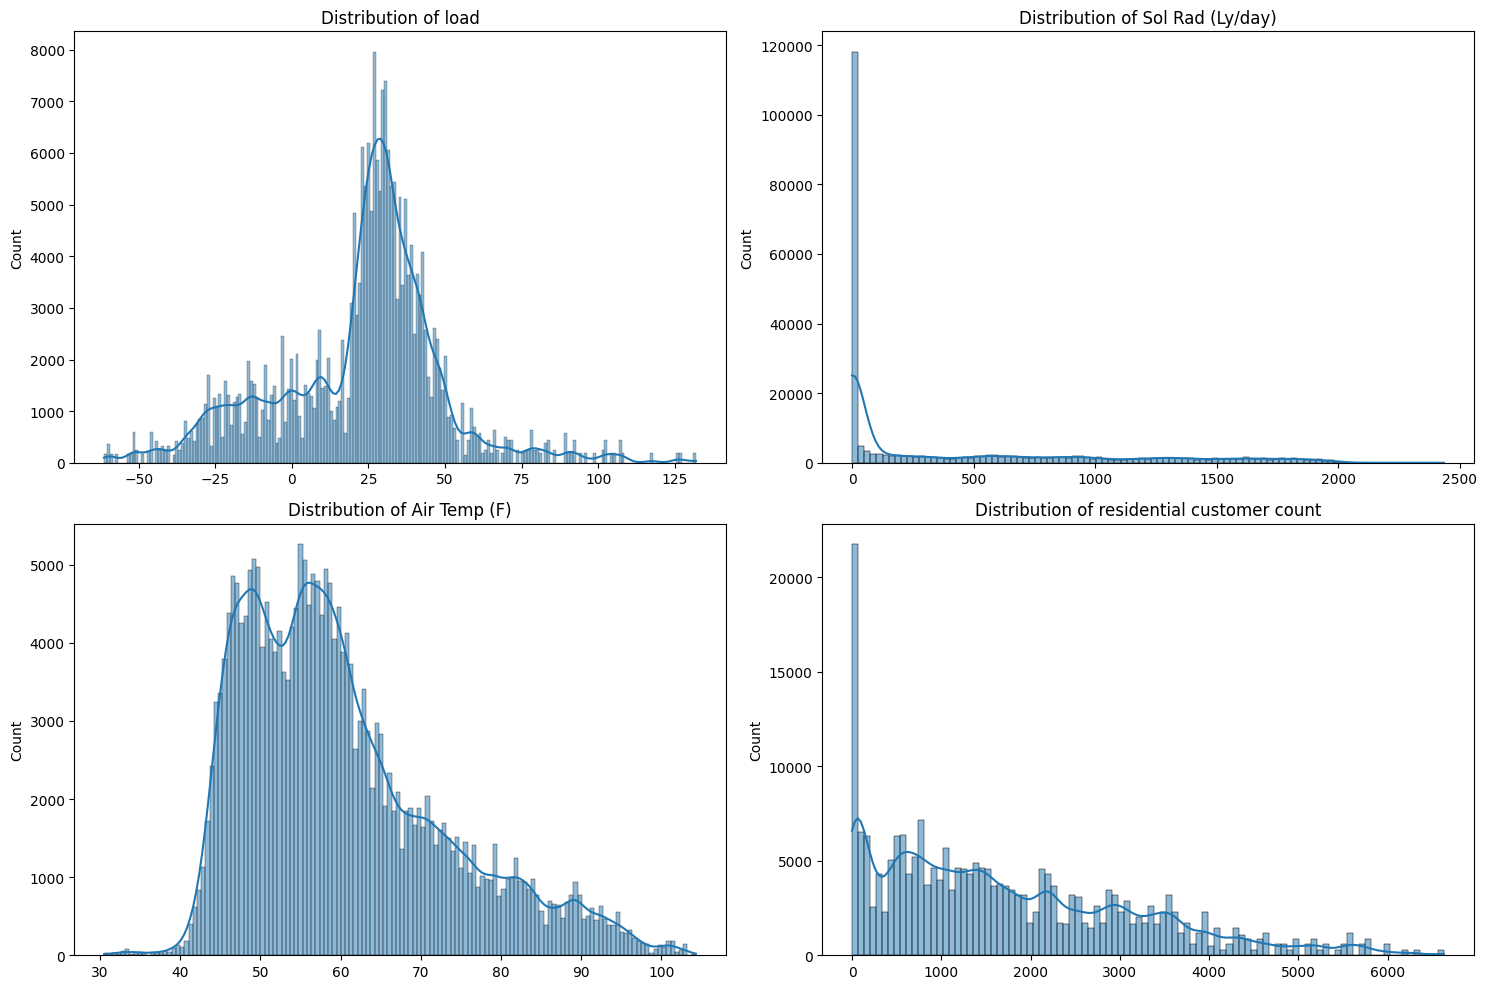

In [ ]:
features_to_plot = [
    'load',
    'Sol Rad (Ly/day)',
    'Air Temp (F)',
    'residential customer count'
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(features_to_plot):
    if feature in X.columns:
        sns.histplot(X[feature], kde=True, ax=axes[idx])
        axes[idx].set_title(f'Distribution of {feature}')
        axes[idx].set_xlabel('')
    else:
        axes[idx].set_visible(False)
        print(f"Warning: feature '{feature}' not found in X.columns")

plt.tight_layout()
plt.show()


This figure shows the distribution of ZIP-level electric vehicle (EV) adoption growth from 2023 to 2024, plotted on a logarithmic scale to capture the wide range of growth rates. Each point represents a ZIP code, while the red horizontal line indicates the average year-over-year growth rate of approximately 41%. Most ZIP codes cluster between roughly 15% and 60% growth, indicating widespread and substantial EV adoption across the region rather than growth being confined to a few isolated areas. At the same time, the presence of several extreme high-growth outliers—some exceeding 200% and approaching 1000% growth—suggests that a small number of ZIP codes are experiencing rapid, possibly early-stage or infrastructure-driven adoption surges. The log scale highlights that while average growth is already very high, the variability across ZIP codes is even more pronounced. From a planning perspective, this heterogeneity implies that EV-driven load growth pressure will be highly uneven geographically, reinforcing the need for ZIP-targeted feeder and charging infrastructure planning rather than uniform system-wide assumptions.

Average YoY Growth: 40.98%


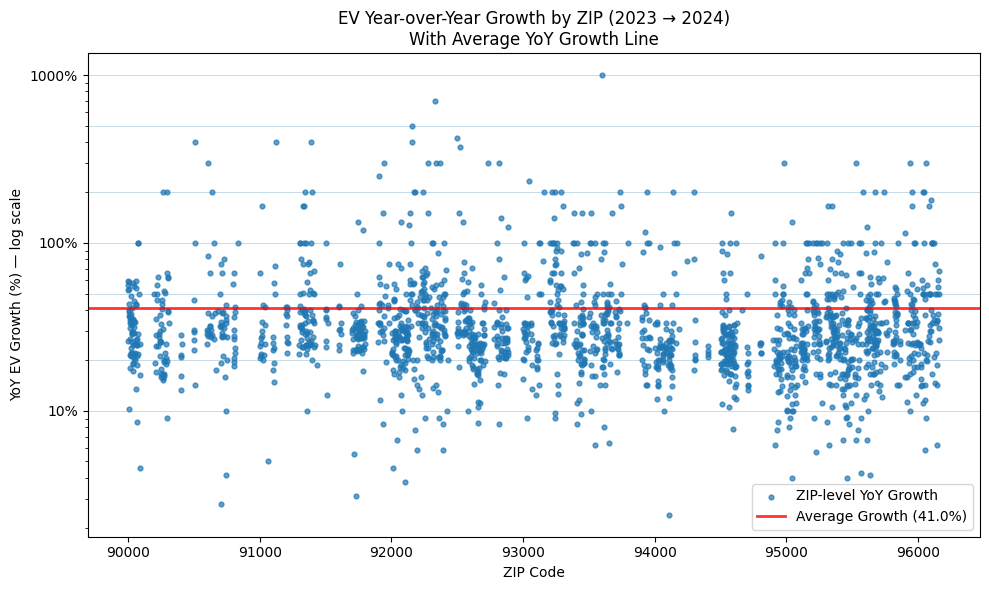

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# 1. Load data
df = pd.read_csv("EV_Pop_Growth_23_24.csv")

# 2. Keep only positive YoY growth
df_filtered = df[df["%change"] > 0].copy()

# 3. Convert fractional YoY values to percent
df_filtered["YoY_percent"] = df_filtered["%change"] * 100

# 4. Compute the mean YoY growth (%)
mean_growth = df_filtered["YoY_percent"].mean()

print(f"Average YoY Growth: {mean_growth:.2f}%") 

# 5. Percentage formatter for log-scale y-axis
def percent_formatter(x, pos):
    return f"{x:.0f}%"

formatter = FuncFormatter(percent_formatter)

# 6. Plot
plt.figure(figsize=(10,6))

plt.scatter(
    df_filtered["Zip Code"],
    df_filtered["YoY_percent"],
    s=12,
    alpha=0.7,
    label="ZIP-level YoY Growth"
)

plt.yscale("log")
plt.gca().yaxis.set_major_formatter(formatter)

# --- Add the average line ---
plt.axhline(
    mean_growth,
    color="red",
    linestyle="-",
    linewidth=2,
    alpha=0.8,
    label=f"Average Growth ({mean_growth:.1f}%)"
)

# Optional reference gridlines
for ref in [10, 20, 50, 100, 200, 500, 1000]:
    plt.axhline(ref, linestyle="-", linewidth=0.6, alpha=0.3)

plt.xlabel("ZIP Code")
plt.ylabel("YoY EV Growth (%) — log scale")
plt.title("EV Year-over-Year Growth by ZIP (2023 → 2024)\nWith Average YoY Growth Line")

plt.legend()
plt.tight_layout()
plt.show()

This figure compares ZIP-code–level EV adoption in 2023 and 2024, showing both individual ZIP values (points) and the system-wide averages (dashed lines). Across nearly all ZIP codes, the 2024 EV counts lie above the corresponding 2023 values, confirming broad-based growth in electric vehicle adoption throughout the study area. The average EV count increases from approximately 659 vehicles per ZIP in 2023 to about 810 in 2024, indicating a substantial overall rise in adoption within just one year.

The distribution is highly right-skewed, with most ZIP codes having relatively modest EV counts, while a small number of ZIPs contain very large EV populations (several thousand to over 10,000 vehicles). This pattern highlights strong geographic concentration of EV adoption. Importantly, the upper tail in 2024 is noticeably heavier than in 2023, showing that high-adoption ZIP codes are pulling even further ahead, which can create localized stress on nearby distribution feeders. From a grid-planning perspective, this reinforces the need for ZIP-targeted infrastructure upgrades and charging coordination, rather than uniform system-wide assumptions about EV load growth.

Average 2023 EVs per ZIP: 659.3
Average 2024 EVs per ZIP: 810.0


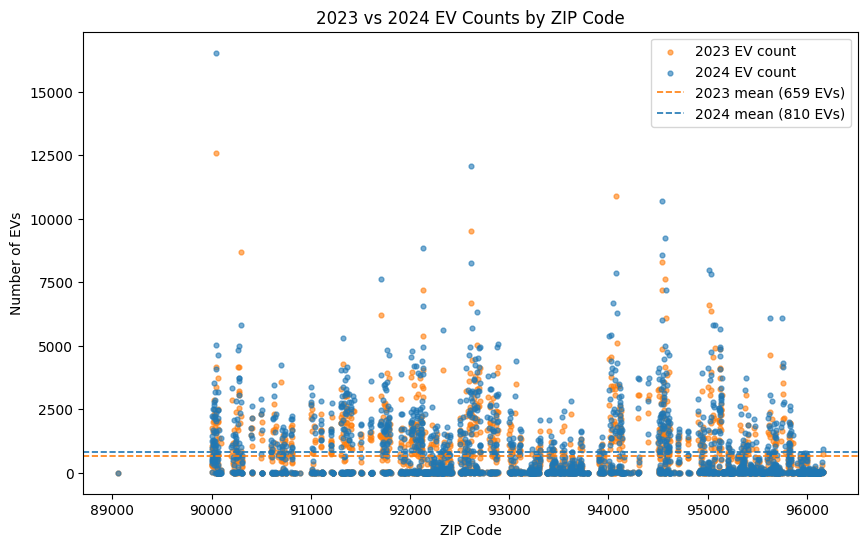

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("EV_Pop_Growth_23_24.csv") 

# 2. Extract columns
zips = df["Zip Code"]
ev_2023 = df["2023"]
ev_2024 = df["2024"]

# 3. Compute means
mean_2023 = ev_2023.mean()
mean_2024 = ev_2024.mean()

print(f"Average 2023 EVs per ZIP: {mean_2023:.1f}")
print(f"Average 2024 EVs per ZIP: {mean_2024:.1f}")

# 4. Plot (with log scale)
plt.figure(figsize=(10, 6))

# Scatter: EV counts
plt.scatter(
    zips,
    ev_2023,
    s=12,
    alpha=0.6,
    color="tab:orange",
    label="2023 EV count"
)

# Scatter: 2024 EV counts
plt.scatter(
    zips,
    ev_2024,
    s=12,
    alpha=0.6,
    color="tab:blue",
    label="2024 EV count"
)

# 5. Add average lines 
plt.axhline(
    mean_2023,
    color="tab:orange",
    linestyle="--",
    linewidth=1.2,
    label=f"2023 mean ({mean_2023:.0f} EVs)"
)

plt.axhline(
    mean_2024,
    color="tab:blue",
    linestyle="--",
    linewidth=1.2,
    label=f"2024 mean ({mean_2024:.0f} EVs)"
)

# 6. Add labels and legend
plt.xlabel("ZIP Code")
plt.ylabel("Number of EVs")
plt.legend()
plt.title("2023 vs 2024 EV Counts by ZIP Code")

# 7. Show plot
plt.show()

CALMAC Load Shape Data:

The CALMAC load shape data provides a detailed picture of how electricity use varies across California’s residential and nonresidential customer groups. The residential and nonresidential GP centroids fall into four clear geographic clusters: Coastal, Inland, North Central Valley, and South Central Valley. These clusters correspond to major climate regions in the state and highlight meaningful geographic variation that likely drives differences in customer behavior and energy use. 
The hourly residential load shape, averaged across more than 1.4 million observations for 2024, shows a strong and predictable daily pattern. Demand is lowest in the late morning and early afternoon and highest in the early evening, when household activity typically peaks. This shape mirrors statewide trends and reinforces how difficult it can be to match residential demand with midday renewable generation.

One notable pattern in the centroid maps is that nonresidential GPs are more spatially interspersed compared to the residential clusters, which form much tighter geographic groupings. This difference reflects how the segmentation schemes were constructed. Residential GPs are explicitly organized around climate zones and solar/load-shape characteristics, so their centroids naturally fall into a small number of clean geographic clusters. Nonresidential GPs, on the other hand, are defined primarily by business type (e.g., Retail, Manufacturing, Office), size class, and other operational characteristics, and not by local climate. Because commercial and industrial activity is distributed unevenly across the state, and because similar business categories appear in many different regions, their centroids scatter more widely rather than forming neat clusters. In short, residential segmentation is geographically driven, whereas nonresidential segmentation is economically/sector driven, leading to a more dispersed centroid pattern. In the nonresidential segment bar chart below, “Proper” refers to property management/real estate. This most likely corresponds to office space. Something that is concerning is that the second largest nonresidential segment is “missin”, which corresponds to values that were not classified.

Our EDA validates that the GP structure of the CALMAC data captures real differences across regions and customer classes, and that these differences meaningfully shape electricity consumption patterns across California. Therefore, it is appropriate to use this data in our modeling.

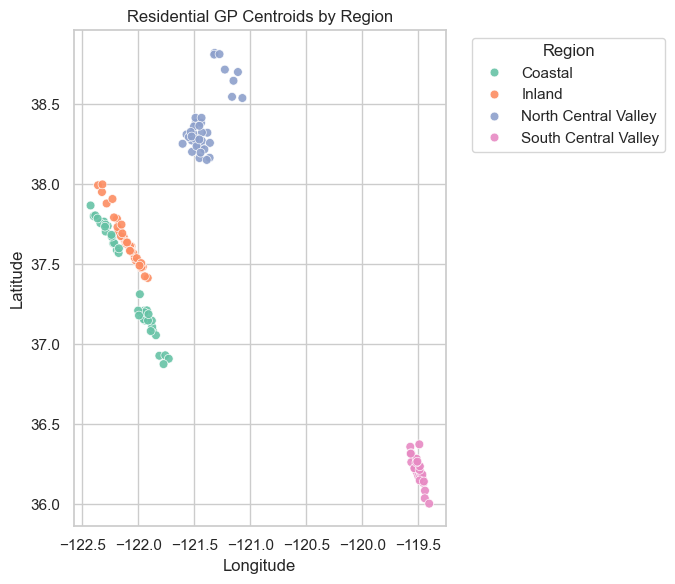

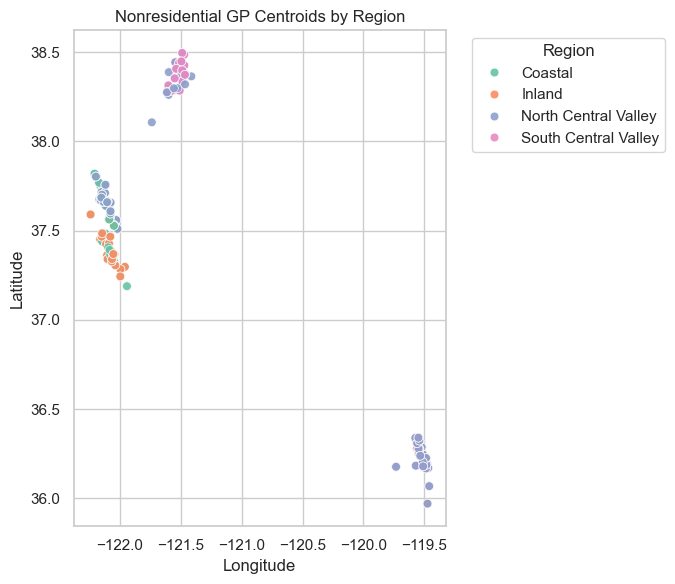


Average residential kWh by hour:
   hour       kwh
0     0  0.843109
1     1  0.767509
2     2  0.717298
3     3  0.688932
4     4  0.686102


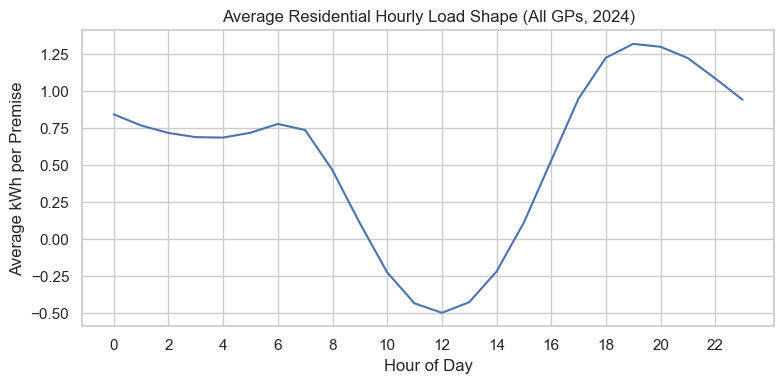


Top 10 nonres segments by prem_count:
seg_ind
Proper    1727
Missin    1698
Retail    1612
Govern    1612
Transp    1607
Office    1601
Health    1598
Lodgin    1595
Grocer    1586
Educat    1584
Name: prem_count, dtype: int64


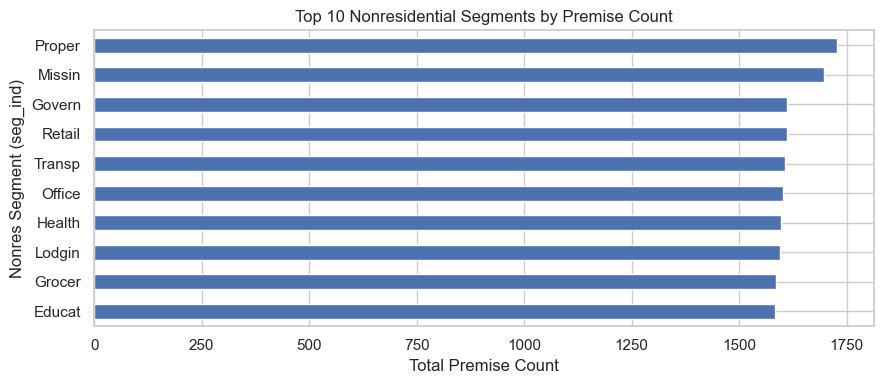


All plots have been displayed.


In [84]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# file paths
PATHS = {
    "res_characteristics": "CALMAC/res_characteristics.csv",
    "res_centroids": "CALMAC/res_centroids.csv",
    "res_gp_elec_2024": "CALMAC/Res_GP_Elec_2024.csv",

    "nonres_characteristics": "CALMAC/nonres_characteristics.csv",
    "nonres_centroids": "CALMAC/nonres_centroids.csv",
    "nonres_segments_counts": "CALMAC/Nonres_Elec_GP_Segments_and_Counts.csv",
}

# load data

dfs = {}
for name, path in PATHS.items():
    df_tmp = pd.read_csv(path)
    dfs[name] = df_tmp

# prepare centroid + region data

# Residential centroids + climate zone (seg_cz)
res_char = dfs["res_characteristics"]
res_cent = dfs["res_centroids"]
res_char_region = res_char[["gp", "seg_cz"]]
res_cent_merged = res_cent.merge(res_char_region, on="gp", how="left")

# nonresidential centroids + climate zone (seg_cz)
nonres_char = dfs["nonres_characteristics"]
nonres_cent = dfs["nonres_centroids"]
nonres_char_region = nonres_char[["gp", "seg_cz"]].drop_duplicates()
nonres_cent_merged = nonres_cent.merge(nonres_char_region, on="gp", how="left")

# plot residential centroid map by region
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=res_cent_merged,
    x="longitude",
    y="latitude",
    hue="seg_cz",      # region
    palette="Set2",
    s=40,
    alpha=0.9,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Residential GP Centroids by Region")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# plot nonresidential centroid map by region
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=nonres_cent_merged,
    x="longitude",
    y="latitude",
    hue="seg_cz",      # region
    palette="Set2",
    s=40,
    alpha=0.9,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Nonresidential GP Centroids by Region")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

# residential average hourly kWh profile
res_gp = dfs["res_gp_elec_2024"]

# average kWh by hour across all segments and days
avg_hourly = (
    res_gp.groupby("hour")["kwh"]
    .mean()
    .reset_index()
    .sort_values("hour")
)

print("\nAverage residential kWh by hour:")
print(avg_hourly.head())

plt.figure(figsize=(8, 4))
sns.lineplot(data=avg_hourly, x="hour", y="kwh")
plt.xlabel("Hour of Day")
plt.ylabel("Average kWh per Premise")
plt.title("Average Residential Hourly Load Shape (All GPs, 2024)")
plt.xticks(range(0, 24, 2))
plt.tight_layout()

plt.show()

# top 10 nonres segments by premise count
nonres_seg = dfs["nonres_segments_counts"]

# sum prem_count by segment industry (seg_ind)
seg_totals = (
    nonres_seg.groupby("seg_ind")["prem_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 nonres segments by prem_count:")
print(seg_totals)

plt.figure(figsize=(9, 4))
seg_totals.sort_values().plot(kind="barh")  # horizontal for readability
plt.xlabel("Total Premise Count")
plt.ylabel("Nonres Segment (seg_ind)")
plt.title("Top 10 Nonresidential Segments by Premise Count")
plt.tight_layout()

plt.show()

print("\nAll plots have been displayed.")

The histogram of feeder headroom (mean_ica_sg) shows a strongly right-skewed distribution measured in kilowatts (kW). Most feeder–hour observations are concentrated at relatively low to moderate headroom levels, largely below about 5,000 kW, with the highest density occurring at the lower end of the range. As headroom increases, the frequency of observations declines steadily, forming a long right tail that extends beyond 15,000 kW. This distribution directly motivates our low–high congestion risk cutoff, as a substantial share of feeders operate within the lower headroom range where congestion is more likely. In contrast, only a small subset of feeders exhibit very high available capacity, indicating that elevated headroom is relatively rare across the system.

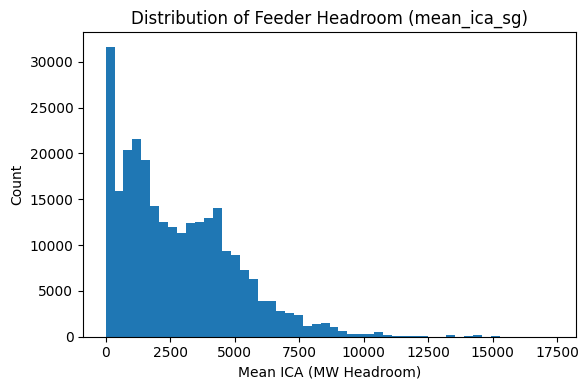

In [60]:
df = pd.read_csv("outputs/feeder_features_cleaned.csv")

plt.figure(figsize=(6,4))
plt.hist(df["mean_ica_sg"].dropna(), bins=50)
plt.xlabel("Mean ICA (MW Headroom)")
plt.ylabel("Count")
plt.title("Distribution of Feeder Headroom (mean_ica_sg)")
plt.tight_layout()
plt.show()

This figure shows feeder-level congestion rates clustered by ZIP code, with ZIP codes ordered from lowest to highest average congestion. Each dot represents a single feeder, and color intensity reflects congestion severity (blue = low, red = high). The plot reveals that most ZIP codes on the left side are dominated by feeders with near-zero congestion, indicating that congestion is not widespread across the system. In contrast, a small group of ZIP codes on the right exhibits a dense concentration of orange and red points, showing that many feeders in these areas are congested for a large fraction of observed month–hours.

The dashed horizontal line at 50% of hours congested highlights a clear threshold separating moderate from severe congestion. Several ZIP codes contain multiple feeders that lie above this threshold, indicating persistent structural congestion rather than isolated or temporary overloads. At the same time, even within high-risk ZIP codes, there remains noticeable variability across feeders, suggesting that local feeder characteristics still play an important role beyond geographic location alone.

Overall, the figure demonstrates that congestion risk is highly geographically concentrated, with a small subset of ZIP codes accounting for most chronic congestion. This supports a targeted, ZIP-specific and feeder-specific resource allocation strategy, rather than broad system-wide upgrades, and helps identify where engineering review and capital investment would be most impactful.

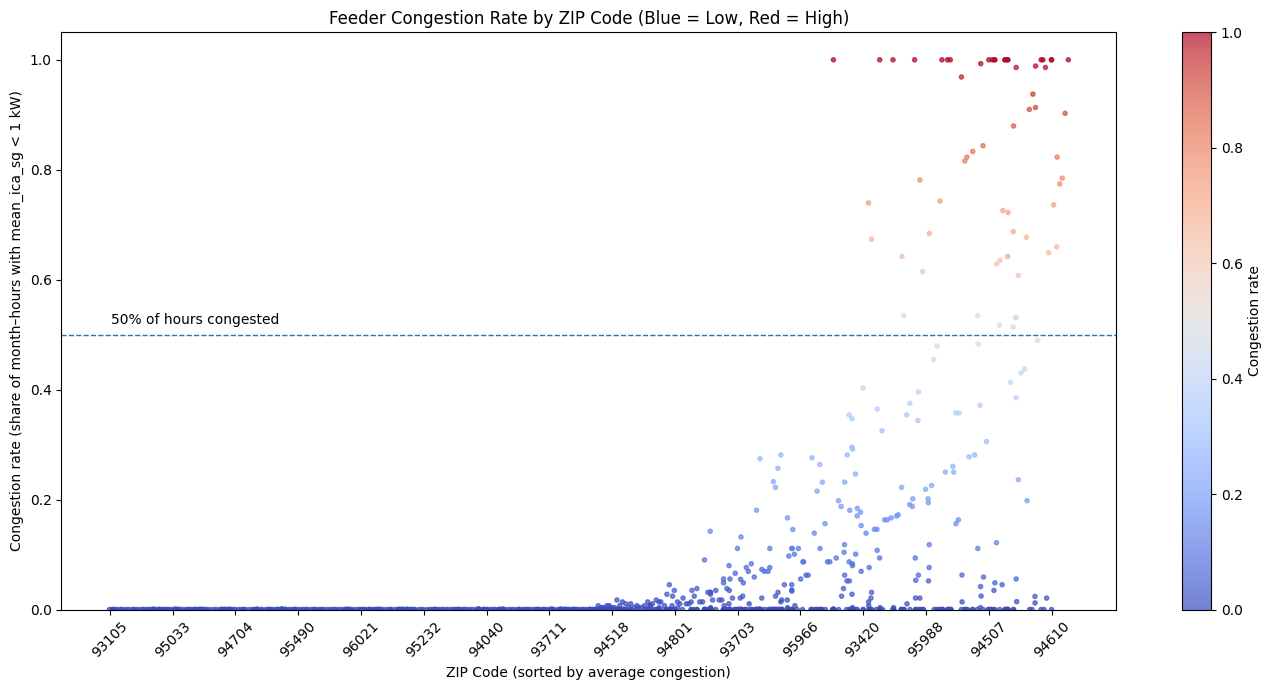

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df["congested"] = (df["mean_ica_sg"] < 1).astype(int)

feeder_stats = (
    df.groupby(["feederid", "ZIP_CODE"])["congested"]
      .agg(["sum", "count"])
      .reset_index()
)
feeder_stats["congestion_rate"] = feeder_stats["sum"] / feeder_stats["count"]
feeder_stats["ZIP_CODE"] = feeder_stats["ZIP_CODE"].astype(str)

# Sort ZIPs by average congestion rate
zip_avg = (
    feeder_stats.groupby("ZIP_CODE")["congestion_rate"]
    .mean()
    .sort_values()
)
sorted_zips = zip_avg.index.tolist()
zip_map = {z: i for i, z in enumerate(sorted_zips)}

feeder_stats["zip_x_base"] = feeder_stats["ZIP_CODE"].map(zip_map)

np.random.seed(42) 
jitter = np.random.uniform(-0.25, 0.25, size=len(feeder_stats))
feeder_stats["zip_x"] = feeder_stats["zip_x_base"] + jitter

plt.figure(figsize=(14, 7))

sc = plt.scatter(
    feeder_stats["zip_x"],
    feeder_stats["congestion_rate"],
    s=9,
    c=feeder_stats["congestion_rate"],
    cmap="coolwarm",   # blue = low, red = high
    alpha=0.7
)

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.text(0.5, 0.52, "50% of hours congested", fontsize=10)

plt.xlabel("ZIP Code (sorted by average congestion)")
plt.ylabel("Congestion rate (share of month–hours with mean_ica_sg < 1 kW)")
plt.title("Feeder Congestion Rate by ZIP Code (Blue = Low, Red = High)")
plt.ylim(0, 1.05)

step = max(1, len(sorted_zips) // 15)
tick_positions = list(range(0, len(sorted_zips), step))
tick_labels = [sorted_zips[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)

cbar = plt.colorbar(sc)
cbar.set_label("Congestion rate")

plt.tight_layout()
plt.show()

## Forecasting and Prediction Modeling (25 points)

This section is where the rubber meets the road.  In it you must:
1. Explore at least 3 prediction modeling approaches for each prediction question, ranging from the simple (e.g. linear regression, KNN) to the complex (e.g. SVM, random forests, Lasso).  
2. Motivate all your modeling decisions.  This includes parameter choices (e.g., how many folds in k-fold cross validation, what time window you use for averaging your data) as well as model form (e.g., If you use regression trees, why?  If you include nonlinear features in a regression model, why?). 
1. Carefully describe your cross validation and model selection process.  You should partition your data into training and testing data sets.  The training data set is what you use for cross-validation (i.e. you sample from within it to create folds, etc.).  The testing data set is held to the very end of your efforts, and used to compare qualitatively different models (e.g. OLS vs random forests).
4. Very carefully document your workflow.  We will be reading a lot of projects, so we need you to explain each basic step in your analysis.  
5. Seek opportunities to write functions allow you to avoid doing things over and over, and that make your code more succinct and readable. 

#### Prediction model 1: Regression:

##### Motivation and Model Selection:

For this prediction problem, we frame feeder congestion as a continuous regression task at the feeder–month–hour level. The target variable is the available headroom in MW (mean_ica_sg), interpreted as the remaining solar hosting capacity on each feeder at a given month–hour. Our feature set combines relatively static feeder attributes (e.g., voltage class, existing distributed generation, customer mix) with more dynamic temporal and environmental variables (month, hour, system load, and weather). The core goal is to estimate “How much headroom will this feeder have at month–hour?”, so that planners can identify feeders where capacity is tightening over time and evaluate the impacts of future DER or load-growth scenarios.


We explore three main families of regression models that span the complexity spectrum: OLS as a simple linear baseline, regularized linear models (Ridge and Lasso regression), and a Random Forest regressor as a flexible, non-linear ensemble model. To evaluate and select models, we partitioned the data into a training set and a held-out test set using an 80/20 split. The training set is used exclusively for model fitting and cross-validation, if that was included on the model, while the test set is held out until the very end for a one-time comparison of final model performance. All linear models (OLS, Ridge, Lasso) are standardized using StandardScaler so that features are on comparable scales. This is especially important for Ridge and Lasso, whose penalties depend on the scale of the coefficients. The Random Forest model does not use standardization, because tree-based models are inherently scale-invariant.


##### Data Processing and Hyperparameter Tuning:

Within the training data for Ridge, Lasso, and Random Forest models, we use k-fold cross-validation (10-folds) to tune hyperparameters and estimate out-of-sample error. For Ridge and Lasso, we cross-validated to select the α that minimizes the average Root Mean Squared Error (RMSE) across folds. For the Random Forest, we tuned a small set of key hyperparameters—such as the number of trees, maximum depth, and minimum samples per leaf—balancing predictive performance against training time. Our primary selection metric is RMSE, since it has the same units as the target (MW headroom) and penalizes larger errors more strongly, although we also report MAE and R² to provide additional context.

Before fitting models, we performed basic feature screening to improve the potential predictive power of models generated. We restricted the predictor set to numeric variables (excluding the target), identified any strictly categorical columns for potential encoding or exclusion, and then computed pairwise correlations and Variance Inflation Factors (VIF) to flag highly collinear predictors. Predictors with extremely high correlation or VIF values are considered for removal in order to reduce instability in OLS and to make the Ridge and Lasso penalties more meaningful. This preprocessing step is implemented in a short diagnostic script that prints detected categorical variables and VIF-based drop candidates.


Loaded data from outputs/feeder_features_cleaned_PhillipEdits_v2.csv
Shape: (266258, 19)
Columns: ['feederid', 'month', 'hour', 'load', '2024', 'mean_ica_sg', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'redacted data', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']

Using feature columns:
['feederid', 'month', 'hour', 'load', '2024', 'Sol Rad (Ly/day)', 'Air Temp (F)', 'Wind Speed (mph)', 'residential customer count', 'commercial customer count', 'industrial customer count', 'agricultural customer count', 'other customers', 'existing distributed generation (kw)', 'queued distributed generation (kw)', 'total distributed generation (kw)', 'voltage']

After dropping missing values:
X shape: (235667, 17)
y length: 235667

Columns with ~zero std:
Series([], dtype: 

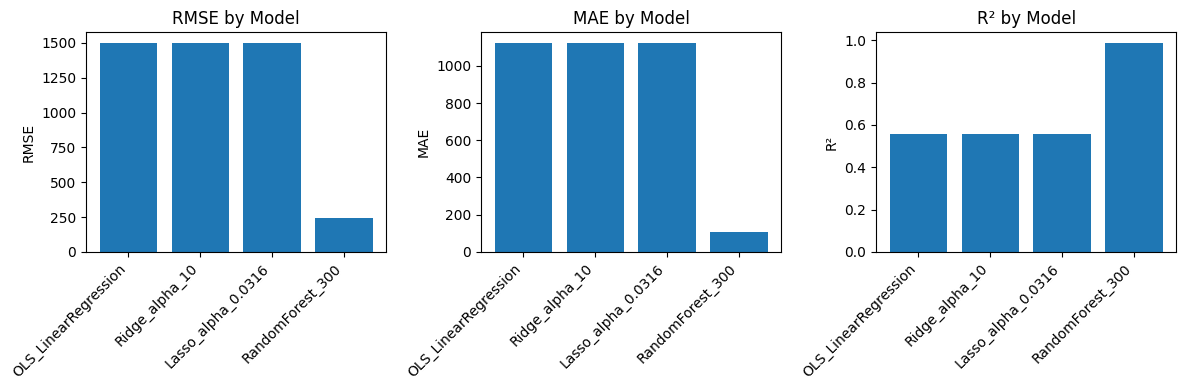


Best model by RMSE: RandomForest_300


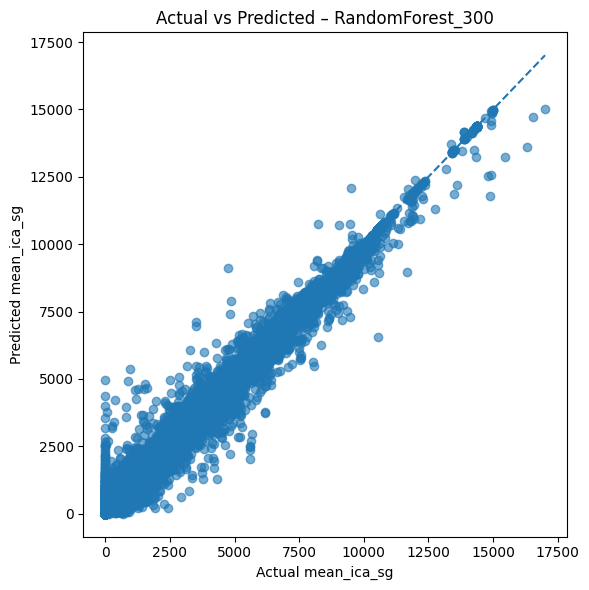

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the data
DATA_PATH = "outputs/feeder_features_cleaned_PhillipEdits_v2.csv"

df = pd.read_csv(DATA_PATH)
print(f"Loaded data from {DATA_PATH}")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

target_col = "mean_ica_sg"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataframe!")


# 2. Set up features/target
numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col != target_col
]

print("\nUsing feature columns:")
print(numeric_cols)

model_df = df[numeric_cols + [target_col]].dropna()
X = model_df[numeric_cols]
y = model_df[target_col]

print("\nAfter dropping missing values:")
print("X shape:", X.shape)
print("y length:", len(y))


# 3. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Just to see if anything is basically constant
stds = X.std(numeric_only=True)
print("\nColumns with ~zero std:")
print(stds[stds < 1e-12])


# 4. Preprocessing (standardize numeric features)
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_cols)],
    remainder='drop'
)


# 5. Define models
reg_models = {
    "OLS_LinearRegression": Pipeline([
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]),
    "Ridge_alpha_10": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=10, random_state=42))
    ]),
    "Lasso_alpha_0.0316": Pipeline([
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=0.0316, max_iter=10000, random_state=42))
    ]),
    "RandomForest_300": Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# 6. Train, evaluate, store results
print("\n" + "="*50)
print("Prediction Problem 1: Regression – Predict mean_ica_sg (MW headroom)")
print("="*50)

results = []

for name, model in reg_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  R²:   {r2:.3f}")

    results.append({
        "model": name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

results_df = pd.DataFrame(results)
print("\nSummary of model performance:")
print(results_df)

# 7. Simple visualizations
plt.figure(figsize=(12, 4))

# RMSE
plt.subplot(1, 3, 1)
plt.bar(results_df["model"], results_df["rmse"])
plt.xticks(rotation=45, ha="right")
plt.title("RMSE by Model")
plt.ylabel("RMSE")

# MAE
plt.subplot(1, 3, 2)
plt.bar(results_df["model"], results_df["mae"])
plt.xticks(rotation=45, ha="right")
plt.title("MAE by Model")
plt.ylabel("MAE")

# R²
plt.subplot(1, 3, 3)
plt.bar(results_df["model"], results_df["r2"])
plt.xticks(rotation=45, ha="right")
plt.title("R² by Model")
plt.ylabel("R²")

plt.tight_layout()
plt.show()

# 8. Actual vs predicted for best model (by RMSE)
best_row = results_df.loc[results_df["rmse"].idxmin()]
best_name = best_row["model"]
print(f"\nBest model by RMSE: {best_name}")

best_model = reg_models[best_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("Actual mean_ica_sg")
plt.ylabel("Predicted mean_ica_sg")
plt.title(f"Actual vs Predicted – {best_name}")
plt.tight_layout()
plt.show()

Three linear models (ordinary least squares, Ridge, and Lasso regression) produced nearly identical performance, with RMSE values around 1501 MW, MAE values near 1124 MW, and an R² of approximately 0.56, showing that linear relationships explain only about half of the variability in mean MW headroom. In contrast, the Random Forest model performed substantially better, achieving an RMSE of 240 MW, an MAE of 106 MW, and an R² of 0.989. This large improvement indicates that mean feeder headroom is governed by strong nonlinear relationships among load, time, weather, customer composition, and distributed generation, which are effectively captured by the Random Forest but not by linear models.

#### Prediction model 2: Binary Classification:

##### Motivation and Model Selection:

To predict whether a feeder becomes congested (below 1 MW of headroom), we tested a mix of simple and complex models: Logistic Regression (two versions), Linear SVM, KNN, and Random Forest. We wanted to see how far simple linear models could go before switching to more flexible nonlinear approaches:

Logistic Regression (Default, Ridge / L2):

We used logistic regression as our starting baseline model because it is simple and easy to interpret. It allows us to clearly see how each feature is related to congestion risk, which makes it helpful for understanding general trends in the data.

Logistic Regression (C = 10, Weaker Regularization):

This version of logistic regression is a less constrained version of the baseline model. By allowing the model to fit the training data more closely, we tested whether reducing the regularization would improve predictions. 

Support Vector Machine (SVM)

The SVM looks for the best separating boundary between congested and non-congested feeders by maximizing the margin between the two groups. 

Random Forest 

The Random Forest model combines many decision trees to make a final prediction. We included this model because feeder congestion is influenced by interacting physical and behavioral factors, which simple linear models cannot fully represent.

K-Nearest Neighbors (KNN)

The KNN model makes predictions by looking at the most similar past observations and using their outcomes to classify new cases. 

##### Data Processing:

Before training any models, we spent time preparing the data so that all models would be learning from clean, comparable, and reliable inputs. Since our dataset contains a mix of numerical and categorical features (such as weather variables, customer counts, and distributed generation), we first converted all categorical variables into numeric form using one-hot encoding. This step allows the models to interpret categories mathematically rather than as text.

Next, we addressed missing values, which are unavoidable in real-world operational datasets. Instead of discarding large portions of the data, we used median imputation to fill in missing numerical values. 

After splitting the data into training (80%) and testing (20%) sets, we applied standardization only after the split to avoid information leakage. Using StandardScaler, we transformed each numerical feature so that it had a "mean of 0 and a standard deviation of 1", based solely on the training data. This step is especially important for models like Logistic Regression, SVM, and KNN, which are sensitive to differences in feature scale. Without standardization, variables such as distributed generation (measured in thousands of kW) would dominate smaller-scale features like wind speed or temperature, leading to biased learning.



##### Hyperparameter Tuning:

To move beyond purely default model settings, we performed light but principled hyperparameter tuning on our main predictive models. For Logistic Regression, we evaluated two values of the regularization parameter C: the default C = 1, which applies moderate Ridge (L2) regularization to prevent overfitting, and a weaker regularization setting C = 10, which allows the model to fit the data more closely. For the Random Forest, we tuned the number of trees (100 and 200), the maximum tree depth (None, 10, and 20), and the minimum number of samples per leaf (1 and 5) using 3-fold cross-validation on the training set, selecting the configuration that maximized recall for congested feeders. For K-Nearest Neighbors (KNN), we tuned the number of neighbors (5, 10, 15, 20, and 30), again using recall as the selection metric. Smaller values of k capture highly local behavior but are more sensitive to noise, while larger values smooth predictions across broader operating conditions. By selecting k through cross-validation, we ensured that the final KNN model reflects a principled balance between bias and variances. The Linear SVM was evaluated using standard regularization settings to serve as an additional linear baseline for comparison against the nonlinear models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

df = pd.read_csv("outputs/feeder_features_cleaned.csv")

df["congested"] = (df["mean_ica_sg"] < 1000).astype(int)

forbidden_cols = [
    "nominal voltage (kv)", "ZIP_CODE", "loadorgen", "2023",
    "%change", "feederid", "redacted data", "voltage", "mean_ica_sg"
]

cols_to_drop = [c for c in forbidden_cols + ["congested"] if c in df.columns]
X = df.drop(columns=cols_to_drop)
y = df["congested"]

X_encoded = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {}

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
models["LogReg_default"] = logreg

logreg_loose = LogisticRegression(C=10, max_iter=1000)
logreg_loose.fit(X_train, y_train)
models["LogReg_C10"] = logreg_loose

svm = LinearSVC()
svm.fit(X_train, y_train)
models["LinearSVM"] = svm

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
}

rf_base = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(
    rf_base, rf_param_grid, cv=3, scoring="recall", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
models["RandomForest_Tuned"] = best_rf

print("Best Random Forest params:", rf_grid.best_params_)

knn_param_grid = {"n_neighbors": [5, 10, 15, 20, 30]}
knn_base = KNeighborsClassifier()
knn_grid = GridSearchCV(
    knn_base, knn_param_grid, cv=3, scoring="recall", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
models["KNN_Tuned"] = best_knn

print("Best KNN params:", knn_grid.best_params_)

results = []

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_scores = clf.decision_function(X_test)
    else:
        y_scores = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_scores) if y_scores is not None else np.nan

    results.append(
        {"model": name, "accuracy": acc, "precision": prec,
         "recall": rec, "roc_auc": auc}
    )

results_df = pd.DataFrame(results)
print(results_df)

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best KNN params: {'n_neighbors': 5}
                model  accuracy  precision    recall   roc_auc
0      LogReg_default  0.800477   0.639439  0.423496  0.840412
1          LogReg_C10  0.800458   0.639365  0.423496  0.840411
2           LinearSVM  0.790844   0.636613  0.338628  0.840974
3  RandomForest_Tuned  0.979531   0.965249  0.950583  0.997409
4           KNN_Tuned  0.953992   0.909267  0.902010  0.986140


##### Results Interpretation:

After tuning, the best Random Forest model ended up using 200 trees, with no limit on how deep the trees can grow, and a minimum leaf size of 1. In simple terms, this means the model works best when it is allowed to be very detailed and flexible, rather than forcing it to stay simple. This tells us that feeder congestion depends on fine-grained, local conditions instead of broad averages. Small differences in weather, load, or customer mix can meaningfully change congestion risk, and the Random Forest is capturing that.

For KNN, the best choice was k = 5, meaning the model looks at only the five most similar past situations to make a prediction. This shows that congestion tends to happen under very specific operating conditions, and the most similar historical cases are the most informative. Using more neighbors would smooth things too much and hide these local effects.

When we compare overall performance, the tuned Random Forest clearly performs the best: It gets almost 98% of all predictions correct, and correctly identifies about 95% of truly congested feeders.

The tuned KNN model also performs well, with over 90% recall, showing that local similarity is a strong predictor of congestion. However, it is still less consistent than the Random Forest and more sensitive to noise.

In contrast, the linear models (Logistic Regression and Linear SVM) perform much worse at detecting congestion, missing more than half of actual congestion events. The fact that Logistic Regression performs the same with both C = 1 and C = 10 confirms that the problem is not about tuning — it’s that congestion simply isn’t a linear process.

<Figure size 640x480 with 0 Axes>

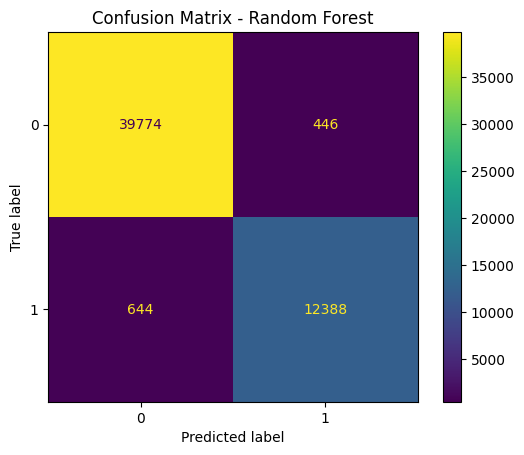

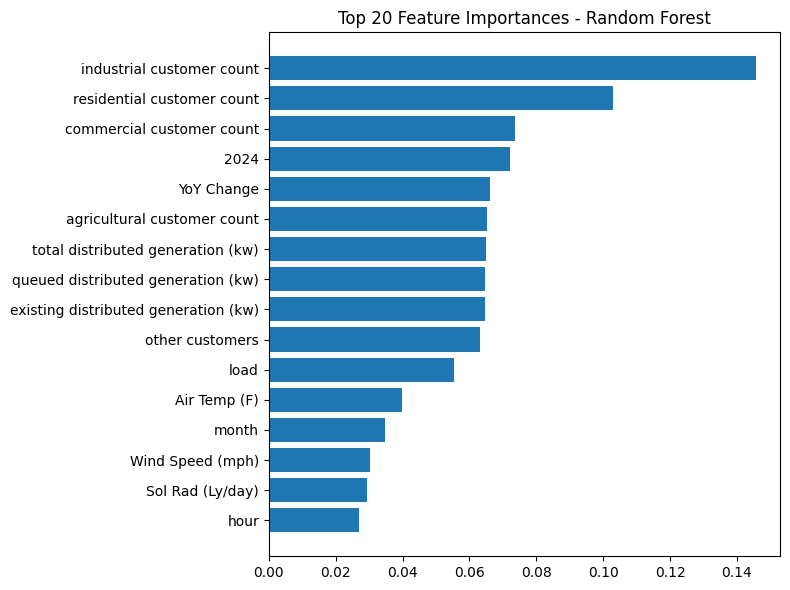

In [21]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure()
disp.plot(values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

importances = models['RandomForest_Tuned'].feature_importances_
feature_names = X_encoded.columns

idx = np.argsort(importances)[-20:]
top_importances = importances[idx]
top_features = feature_names[idx]

plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances)
plt.title("Top 20 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

Since the Random Forest clearly performed the best among all models, we focused our deeper analysis on this model. To better understand both its predictive behavior and practical usefulness, we generated a confusion matrix to examine how well it distinguishes between congested and non-congested feeders in terms of true positives, false positives, true negatives, and false negatives. In addition, we analyzed the feature importance scores produced by the Random Forest to identify which variables contribute most to congestion prediction.

#### Prediction Model 3: Multi-Category Classification:

##### Motivation and Model Selection:

For this prediction problem, we model feeder congestion as a three-tier classification task at the feeder–month–hour level, where the response variable encodes low, medium, and high congestion based on available headroom in MW (e.g., Tier 2 = <1 MW headroom, Tier 1 = 1–5 MW, Tier 0 = >5 MW). Our feature set combines relatively static feeder characteristics (voltage class, customer mix, DER penetration, feeder ID) with more dynamic temporal and environmental variables (month, hour, weather, year indicator). Because the utility ultimately cares about identifying feeders at elevated risk while still having a simple story about why a feeder is risky, we deliberately chose a modeling sequence that moves from interpretable, low-capacity models to more flexible, higher-capacity methods.

We explore three primary modeling approaches that span this complexity spectrum: multinomial logistic regression (softmax) as a linear, baseline classifier; a single decision tree as a non-linear but still highly interpretable model; and a random forest as a more complex ensemble method capable of capturing higher-order interactions and non-linearities. Logistic regression serves as our “workhorse baseline” because it is fast, relatively robust, and produces coefficients that can be directly interpreted as feature effects on the log-odds of each congestion tier. The decision tree relaxes the linearity assumption and can represent threshold-based rules (e.g., “if voltage is low and industrial customers are high, then Tier 2”) that are closer to how engineers reason about feeders. Finally, the random forest aggregates many de-correlated trees to reduce variance and overfitting, making it a natural candidate for improved predictive performance on a large dataset with potential interactions between customer mix, DER, and temporal variables. We do not prioritize methods like KNN or SVM here: KNN scales poorly to ~260k observations and many features, and SVMs (especially non-linear kernels) tend to be computationally intensive and less interpretable at this scale, offering less added value than tree ensembles for our use case.


##### Data Processing and Hyperparameter Tuning:

To evaluate these models, we partition the data into a training set and a held-out test set (roughly 80/20) using a stratified split by congestion tier so that the class imbalance in the full data (Tier 1 much more common than Tier 0 and Tier 2) is preserved in both subsets. Model selection and hyperparameter tuning are performed only on the training data, using k-fold cross-validation (e.g., 5-fold stratified CV) to compare candidate configurations for each model while avoiding overfitting to a single split. For example, for the decision tree we vary parameters like maximum depth and minimum samples per leaf; for logistic regression we consider the strength of regularization; and for the random forest we tune the number of trees and tree depth. Because our main concern is performance across all three congestion tiers, and not just the majority class, we focus on macro-averaged F1 as our primary cross-validation metric, while also reporting overall accuracy and the per-class precision/recall on the held-out test set for interpretability.

Throughout the workflow, we structure our code to be modular and reusable, both to keep it readable and to avoid repeating the same evaluation logic for each model. In practice, this means writing helper functions that: (1) take a scikit-learn model plus training and test data, (2) fit the model, (3) generate predictions, (4) compute and print accuracy, macro F1, and a full classification report, and (5) optionally extract and display feature importances or coefficients where available. This functional structure makes it easy to swap in different models or hyperparameter settings while preserving a consistent evaluation pipeline, and it keeps the modeling narrative transparent: define the prediction question, choose a family of models for clear reasons, tune them via cross-validation on the training set, and only then compare their final performance on the untouched test set.


In [34]:
# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)

# 2. Load data
csv_path = "outputs/feeder_features_cleaned_PhillipEdits_v2.csv"
df = pd.read_csv(csv_path)

response_col = "mean_ica_sg"
df = df.dropna(subset=[response_col])

# 3. Define features and create 3-class target variable
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != response_col]

X = df[feature_cols]
headroom = df[response_col]

# Define 3 risk tiers
conditions = [
    headroom > 5000.0,
    (headroom >= 1000.0) & (headroom <= 5000.0),
    headroom < 1000.0,
]
choices = [0, 1, 2]
y_tier = np.select(conditions, choices).astype(int) 

print("\nTier distribution:")
print(pd.Series(y_tier).value_counts().sort_index())

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_tier,
    test_size=0.2,
    random_state=42,
    stratify=y_tier,  #ensure train and test sets are balanced 
)

# 5. Helper function for printing metrics
def print_multiclass_metrics(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n{label}")
    print(f"Accuracy: {acc:.3f}")  #float 3 decimals
    print(f"Macro F1: {macro_f1:.3f}")
    print("Classification report:")
    print(classification_report(y_true, y_pred))

# 6. Model Training
# (A) Logistic Regression 
log_model = make_pipeline(
    SimpleImputer(strategy="median"),  # Use median imputation to handle missing numeric values robustly.
    StandardScaler(),  # Scale features because logistic regression performs best on standardized data.
    LogisticRegression(
        multi_class="multinomial",   # Use true multinomial (softmax) for multi-class prediction instead of one-vs-rest.
        solver="lbfgs",   # LBFGS is stable and efficient for multinomial logistic regression.
        max_iter=500,  # Increase iterations to ensure the model converges on a large dataset.
        random_state=42   # Fix random seed for reproducible model behavior.
    ),
)

# (B) Decision Tree
dt_model = make_pipeline(
    SimpleImputer(strategy="median"), # Fill missing numeric values with the median to avoid losing data.
    StandardScaler(),  # Included for pipeline consistency; trees are scale-invariant.
    DecisionTreeClassifier(
        max_depth=5,  # Limit tree depth to prevent overfitting and improve generalization.
        min_samples_leaf=50,  # Require at least 50 samples per leaf to smooth out noisy splits.
        random_state=42, # Fix random seed for reproducible tree structure.
    ),
)

# (C) Random Forest
rf_model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
)

results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, average="macro"),
    "Recall": recall_score(y_test, y_pred_log, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_log, average="macro")
})

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, average="macro"),
    "Recall": recall_score(y_test, y_pred_dt, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_dt, average="macro")
})

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average="macro"),
    "Recall": recall_score(y_test, y_pred_rf, average="macro"),
    "Macro F1": f1_score(y_test, y_pred_rf, average="macro")
})

results_df = pd.DataFrame(results)
print(results_df.round(3))


Tier distribution:
0     42459
1    158640
2     65159
Name: count, dtype: int64
                 Model  Accuracy  Precision  Recall  Macro F1
0  Logistic Regression     0.696      0.681   0.608     0.634
1        Decision Tree     0.732      0.747   0.624     0.662
2        Random Forest     0.970      0.968   0.967     0.968


This table compares overall performance across the three models.
The random forest dramatically outperforms both logistic regression and the decision tree, achieving very high accuracy and macro-F1, while the other two models show moderate performance and struggle with class imbalance.


<Figure size 600x500 with 0 Axes>

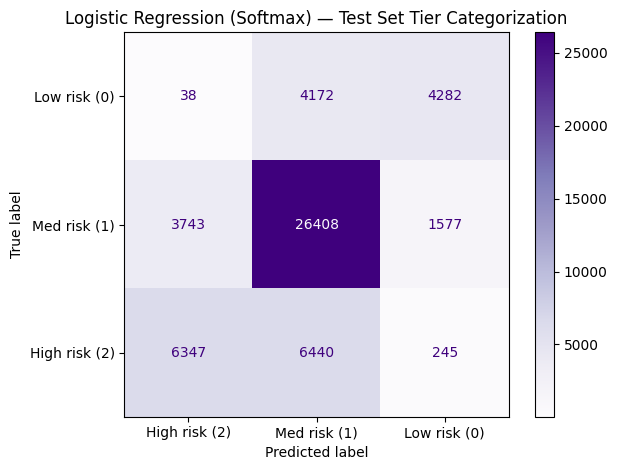

<Figure size 600x500 with 0 Axes>

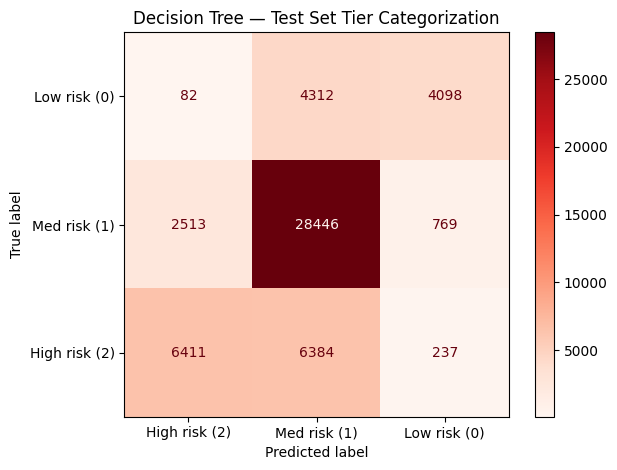

<Figure size 600x500 with 0 Axes>

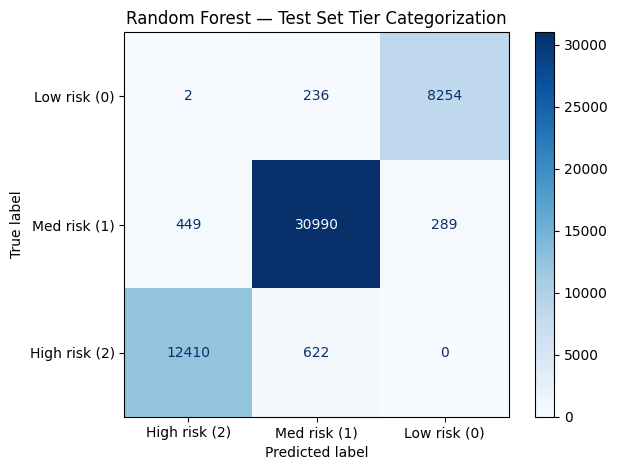

In [ ]:
# 7. Visualizations - here we plot our results as confusion matrices
tier_labels = ["Low risk (0)", "Med risk (1)", "High risk (2)"]

# Logistic Regression Confusion Matrix 
cm_log = confusion_matrix(y_test, y_pred_log, labels=[0, 1, 2])
# Reverse the columns for x-axis reversal
cm_log_reversed = cm_log[:, ::-1]

# Create custom display with reversed labels for x-axis
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log_reversed, 
                                  display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_log.plot(cmap="Purples", values_format="d")
plt.title("Logistic Regression (Softmax) — Test Set Tier Categorization")

# Manually set the y-axis labels in the correct order
ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])  # Keep x-axis reversed

plt.tight_layout()
plt.show()

# Decision Tree Confusion Matrix 
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[0, 1, 2])
cm_dt_reversed = cm_dt[:, ::-1]

disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt_reversed, 
                                 display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_dt.plot(cmap="Reds", values_format="d")
plt.title("Decision Tree — Test Set Tier Categorization")

ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])

plt.tight_layout()
plt.show()

# Random Forest Confusion Matrix 
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[0, 1, 2])
cm_rf_reversed = cm_rf[:, ::-1]

disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf_reversed, 
                                 display_labels=tier_labels[::-1])

plt.figure(figsize=(6, 5))
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Random Forest — Test Set Tier Categorization")

ax = plt.gca()
ax.set_yticklabels(tier_labels)
ax.set_xticklabels(tier_labels[::-1])

plt.tight_layout()
plt.show()

In [79]:
print("len(y_test):        ", len(y_test))
print("len(y_pred_log):    ", len(y_pred_log))
print("len(y_pred_dt):     ", len(y_pred_dt))
print("len(y_pred_rf):     ", len(y_pred_rf))

len(y_test):         47134
len(y_pred_log):     53252
len(y_pred_dt):      53252
len(y_pred_rf):      53252


In [78]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

tier_labels = ["Low (0)", "Med (1)", "High (2)"]
class_order = [0, 1, 2]   # order of your tiers

def metric_table(y_true, y_pred, class_order, tier_labels, model_name):
    """Return a nice DataFrame of metrics for one model."""
    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=class_order, zero_division=0
    )

    df = pd.DataFrame({
        "Tier": tier_labels,
        "Precision": p,
        "Recall": r,
        "F1-score": f1,
        "Support": support
    })

    df.insert(0, "Model", model_name)
    return df

# Build tables for each model
table_log = metric_table(y_test, y_pred_log, class_order, tier_labels, "Logistic Regression")
table_dt  = metric_table(y_test, y_pred_dt,  class_order, tier_labels, "Decision Tree")
table_rf  = metric_table(y_test, y_pred_rf,  class_order, tier_labels, "Random Forest")

# If you want them stacked into one big table:
all_tables = pd.concat([table_log, table_dt, table_rf], ignore_index=True)
all_tables


ValueError: Found input variables with inconsistent numbers of samples: [47134, 53252]

Logistic regression provides a solid linear baseline but struggles with Tier 0 and Tier 2 due to its limited capacity to model non-linear patterns. It performs best on the majority Tier 1 class, with noticeably lower recall for high-risk feeders.

The decision tree improves on logistic regression by capturing non-linear thresholds, especially boosting Tier 1 performance, but still misses many Tier 0 and Tier 2 cases. Its overall performance is moderate, reflecting the limitations of using a shallow, interpretable model on a complex classification task.

The random forest achieves excellent performance across all tiers, with high precision, recall, and F1, indicating strong ability to capture complex interactions in the data. Its consistently high scores suggest far better predictive power, though it may risk overfitting compared to simpler models.


## Resource Allocation and Conclusions (20 points)
In this section you must relate your modeling and forecasting results to your original prediction question.  You must:
1. Address a resource allocation question.  What do the answers mean? What advice would you give a decision maker on the basis of your results?  How might they allocate their resources differently with the results of your model?  Why should the reader care about your results?  *To get full marks you must provide both a qualitative and quantitative analysis.*
2. Discuss caveats and / or reasons your results might be flawed.  No model is perfect, and understanding a model's imperfections is extremely important for the purpose of knowing how to interpret your results.  Often, we know the model output is wrong but we can assign a direction for its bias.  This helps to understand whether or not your answers are conservative.  

The purpose of this project was to see whether feeder-level headroom and congestion risk could be predicted using publicly available data on load, weather, customer mix, and DER adoption. The three prediction problems taken together show that feeder behavior is patterned enough that models can provide useful guidance, although with meaningful uncertainty. The Random Forest generally performed better than linear models in every task, suggesting that congestion depends on interactions across several variables rather than simple trends. These results help link the forecasts to practical decisions about where to invest limited utility resources, which feeders should be monitored more closely, and where new DER projects are most likely to be feasible.

For the first prediction problem, the model estimating month-hour feeder load gives planners a rough sense of how much headroom remains before reaching a thermal or ICA limit. The Random Forest model’s errors were approximately 240 kW, which is small compared to feeders in the 10 to 15 MW range. This accuracy allows planners to use the predictions as one input when reviewing DER interconnection requests or assessing whether a feeder might need additional support. For instance, if a feeder has a 12 MW limit and the model predicts a load near 10.5 MW, that suggests that a small solar project or EV charger could likely be approved without major concern. If the forecast is closer to 11.7 or 11.8 MW, the feeder may need a closer look or a more conservative upgrade timeline. These insights can help prevent unnecessary upgrades, reduce delays, and direct funds toward feeders that appear to be trending toward constraint.

The second prediction problem shifts the focus to identifying whether a feeder is likely to fall under a 1 MW headroom threshold. This helps with medium-term prioritization. Feeders flagged as congested during specific month-hour combinations could be candidates for closer monitoring, targeted demand response, or accelerated upgrades. The Random Forest again performed best, with high accuracy and recall, meaning it caught most of the true congested cases. If a feeder shows recurring congestion in certain months or hours, utility planners might schedule field inspections, AMI data checks, or operational adjustments. Feeders that rarely appear congested could have upgrades deferred, freeing resources for higher-risk areas. Still, these predictions should be viewed as broad risk signals rather than definitive operational outcomes.

The third prediction problem assigns observations into low, medium, or high congestion tiers, which helps longer-term planning and triage. The Random Forest captured the majority of high-risk cases, while simpler models struggled. If a feeder repeatedly falls into the highest-risk tier, that suggests it should be considered seriously for future capital planning. Feeders that sit mainly in the middle tier might not require immediate upgrades but could become riskier as electrification and DER adoption increase. This tiered approach helps utilities organize multi-year budgets and identify which locations may need more detailed engineering study.

Despite the strong performance of the Random Forest models, there are several sources of uncertainty that limit how confidently the results should be interpreted. The data were aggregated to the month-hour level, which smooths out sharp load spikes and extreme weather events. This means that true peak stress may be higher than the model predicts. EV adoption data were only available annually at the ZIP code level, and this likely understates short-term charging impacts. Weather data were matched to feeders through ZIP codes and regional weather stations, which may not fully capture local microclimates. These factors tend to bias estimates downward, suggesting that the model may understate congestion during unusual or extreme conditions.

The models are also purely data-driven. They do not enforce power system physics such as thermal limits, voltage performance, protection behavior, or feeder topology. If future operating conditions differ significantly from the historical data, such as rapid electrification or very high DER penetration, the models may not generalize well. The tiered classification problem is affected by class imbalance, making it easier for some models to default to the most common category. Even the Random Forest, though more accurate, may still overfit feeder-specific behaviors that would not transfer to other systems or future years.

Taken together, these limitations suggest that the results should be treated as helpful planning guidance rather than exact operational predictions. The uncertainty generally leans toward underestimating congestion risk, meaning that feeders identified as high-risk should be taken seriously, while feeders labeled low-risk should still be monitored with some caution. Even with these caveats, the models provide a practical and lightweight way to complement engineering studies and help utilities target upgrades, manage DER growth, and prioritize monitoring. By focusing resources where they are most likely to matter, utilities can improve reliability while supporting broader electrification and clean energy goals.
